In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rushilprajapati/data-final")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'data-final' dataset.
Path to dataset files: /kaggle/input/data-final
Contents of base_path (/kaggle/input):
['data-final']
Contents of path (/kaggle/input/data-final):
['data']


In [ ]:
import os

# Path to 'data' folder
data_folder_path = os.path.join(path, 'data')

if os.path.exists(data_folder_path):
    contents = os.listdir(data_folder_path)
    print(f"Contents in 'data' folder ({data_folder_path}):")
    display(contents)

    # Deeper check for subdirectories
    for item in contents[:5]: # Check the first 5 items
        item_path = os.path.join(data_folder_path, item)
        if os.path.isdir(item_path):
            print(f"\nSubfolder '{item}' contains: {os.listdir(item_path)[:10]}...")
else:
    print("Data folder not found.")

Contents in 'data' folder (/kaggle/input/data-final/data):


['Blot-Gel',
 'Histopathology',
 'FACS',
 'Macroscopy',
 'Non-scientific',
 'Microscopy']


Subfolder 'Blot-Gel' contains: ['060200 (3).png', '060701.png', '020201 (5).png', '030004 (3).png', '080503.png', '050402 (2).png', '070101 (2).png', '010000 (3).png', '040104 (2).png', '060101 (3).png']...

Subfolder 'Histopathology' contains: ['image_978 (2).png', 'image_2304 (2).png', 'image_339 (2).png', 'image_1796 (2).png', 'image_281.png', 'image_418.png', 'image_1310 (2).png', 'image_2614.png', 'image_1079 (2).png', 'image_2231.png']...

Subfolder 'FACS' contains: ['020201 (5).png', '030004 (3).png', '060105 (3).png', '070101 (2).png', '010000 (3).png', '040104 (2).png', '060101 (3).png', '030008 (3).png', '030015.png', '010003 (3).png']...

Subfolder 'Macroscopy' contains: ['77350309-7fdf-4680-aa75-f70bcfd8de3f.jpg', 'de707955-c27c-45b5-920d-81d107a33c91.jpg', '9acd595c-e8e0-422b-a644-409439ebb01b.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg', 'ISIC_0028872.jpg', '020201 (5).png', 'cedb950b-325a-4c91-8a13-247c260e4163.jpg', '030004 (3).png', '1-3-46-670589-33-1-637380981940983

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Set source and destination paths
source_dir = data_folder_path
base_split_dir = '/content/dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
test_dir = os.path.join(base_split_dir, 'test')

# Create train/test directories
for d in [train_dir, test_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# Get list of classes (subfolders in 'data')
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
    cls_source_path = os.path.join(source_dir, cls)

    # Create subfolders for each class in train and test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Get list of all image files
    images = [f for f in os.listdir(cls_source_path) if os.path.isfile(os.path.join(cls_source_path, f))]

    if len(images) > 0:
        # Split with 8/2 ratio
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        # Copy files to respective directories
        for img in train_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(train_dir, cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(test_dir, cls, img))

        print(f"Class '{cls}': {len(train_imgs)} train images, {len(test_imgs)} test images.")

print("\nDataset split completed at:", base_split_dir)

Class 'Blot-Gel': 1500 train images, 375 test images.
Class 'Histopathology': 4143 train images, 1036 test images.
Class 'FACS': 856 train images, 214 test images.
Class 'Macroscopy': 3569 train images, 893 test images.
Class 'Non-scientific': 4008 train images, 1002 test images.
Class 'Microscopy': 1207 train images, 302 test images.

Dataset split completed at: /content/dataset_split


In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Please ensure GPU is enabled in Edit -> Notebook settings.')
else:
  print(f'Found GPU at: {device_name}')

# List available physical devices
print("Physical Devices:", tf.config.list_physical_devices())


Found GPU at: /device:GPU:0
Physical Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Configuration
img_size = (299, 299) # InceptionV3 default size
batch_size = 32

# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False # Freeze base model for initial training

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.2)(x)
predictions = layers.Dense(len(classes), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=10
)

Found 15283 images belonging to 6 classes.
Found 3822 images belonging to 6 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 447s 893ms/step - accuracy: 0.9524 - loss: 0.1533 - val_accuracy: 0.9617 - val_loss: 0.1204
Epoch 2/10
  1/477 ━━━━━━━━━━━━━━━━━━━━ 57s 120ms/step - accuracy: 1.0000 - loss: 0.0192

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


477/477 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 0.9630 - val_loss: 0.1106
Epoch 3/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 439s 840ms/step - accuracy: 0.9761 - loss: 0.0768 - val_accuracy: 0.9743 - val_loss: 0.0704
Epoch 4/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.9688 - loss: 0.1021 - val_accuracy: 0.9724 - val_loss: 0.0775
Epoch 5/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 403s 845ms/step - accuracy: 0.9812 - loss: 0.0566 - val_accuracy: 0.9795 - val_loss: 0.0663
Epoch 6/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.9774 - val_loss: 0.0782
Epoch 7/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 397s 833ms/step - accuracy: 0.9856 - loss: 0.0450 - val_accuracy: 0.9737 - val_loss: 0.0763
Epoch 8/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9737 - val_loss: 0.0811
Epoch 9/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 396s 829ms/step - accuracy: 0.9840 - loss: 0.0490 - val

In [ ]:
# Summary of Training Results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.9688
Final Validation Accuracy: 0.9709
Final Training Loss:       0.0917
Final Validation Loss:     0.0836


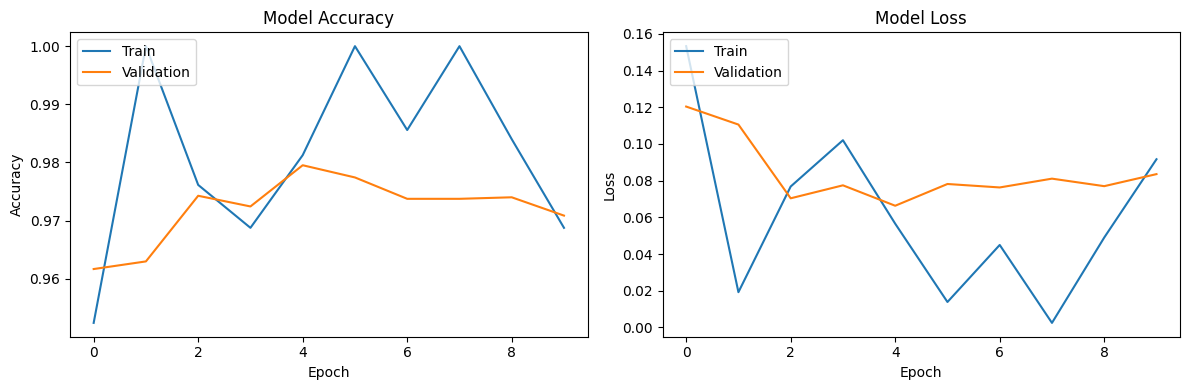

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()